In [1]:
!uv add -U datasets
!uv add fsspec==2023.9.2

Resolved 69 packages in 244ms                                        
Audited 65 packages in 14ms
Resolved 69 packages in 2ms
Audited 65 packages in 1ms


In [2]:
!uv add catboost "datasets" scikit-learn pandas langdetect tqdm matplotlib seaborn

Resolved 69 packages in 2ms
Audited 65 packages in 0.85ms


In [ ]:
# ------------------------------------------------------------------
# 1) Imports
# ------------------------------------------------------------------
from datasets import load_dataset
from transformers import AutoTokenizer
import pandas as pd, numpy as np, re, math, random, gc, tqdm
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from langdetect import detect
import matplotlib.pyplot as plt ; import seaborn as sns
sns.set_theme(style="ticks"); plt.rcParams["figure.dpi"]=120
random.seed(42); np.random.seed(42)

tokenizer = AutoTokenizer.from_pretrained("gpt2", use_fast=True)

from catboost.utils import get_gpu_device_count

USE_GPU = get_gpu_device_count() > 0

# ------------------------------------------------------------------
# 2) Helper – feature engineering
# ------------------------------------------------------------------
KEYWORDS = [
    "list", "summarize", "explain", "translate", "write code", "example",
    "how", "why", "what", "compare", "advantages", "disadvantages"
]
IDF_CORPUS = {}    # Lazy-filled simple token->docfreq map
KW2SAFE = {kw: re.sub(r"[^\w]+", "_", kw) for kw in KEYWORDS}

def shannon_entropy(text:str)->float:
    if not text: return 0.0
    prob = [c/len(text) for c in np.unique(list(text),return_counts=True)[1]]
    return -float(np.sum([p*math.log2(p) for p in prob if p>0]))

def build_features(df:pd.DataFrame)->pd.DataFrame:
    # Basic length counts
    df["char_count"]  = df["prompt"].str.len()
    df["word_count"]  = df["prompt"].str.split().apply(len)
    # Structural cues
    df["has_code_fence"]   = df["prompt"].str.contains(r"```").astype(int)
    df["has_question_mark"]= df["prompt"].str.contains(r"\?").astype(int)
    df["num_paragraphs"]   = df["prompt"].str.count(r"\n\n") + 1
    # Lexical keyword binary flags
    for kw, safe_kw in KW2SAFE.items():
        df[f"kw_{safe_kw}"] = df["prompt"].str.contains(kw, flags=re.IGNORECASE).astype(int)
    # Entropy
    df["entropy"] = df["prompt"].apply(shannon_entropy)
    # Very-rough IDF (document freq over corpus)
    global IDF_CORPUS
    if not IDF_CORPUS:         # build once
        toks = df["prompt"].str.split().explode()
        counts = toks.value_counts()
        IDF_CORPUS = counts.to_dict()
    # Average IDF of prompt words (smaller count -> rarer -> higher idf)
    df["avg_idf"] = df["prompt"].apply(
        lambda p: np.mean([ math.log10(len(IDF_CORPUS)/(1+IDF_CORPUS.get(w,1)))
                            for w in p.split()]) if p else 0.0)
    # Language ID (langdetect; wrap in try/except for edge cases)
    def safe_detect(txt):
        try: return detect(txt)
        except: return "unk"
    df["lang"] = df["prompt"].apply(safe_detect)

    return df

# ------------------------------------------------------------------
# 3) Dataset assembly – Dolly, ShareGPT, OpenOrca, Alpaca
# ------------------------------------------------------------------
DATASETS_INFO = [
    # dataset_name,  split, prompt_fields(lambda row -> prompt),  response_field
    ("databricks/databricks-dolly-15k"  , "train",
        lambda s: (s["instruction"] + " " + (s.get("context") or "")).strip(), "response"),
    ("Open-Orca/OpenOrca"               , "train",
        lambda s: s["system_prompt"] + " " + s["question"] if s.get("system_prompt") else s["question"], "response"),
    ("tatsu-lab/alpaca"                 , "train",
        lambda s: s["instruction"] + " " + (s.get("input") or ""), "output"),
    ("theblackcat102/sharegpt-english" , "train",
        # ShareGPT is a list of messages; we take the first user message
        lambda s: next((m["content"] for m in s["conversations"] if m["from"]=="human"), ""),
        # and response is the first assistant part
        "conversations"),
    ("sentence-transformers/eli5", "train",
        lambda s: (s["question"]).strip(), "answer")
]

# Token length = space-split word count by default (fast). Adjust if you prefer a BPE tokenizer.
N_SAMPLES_PER_SET = 10000   # tweak for bigger runs

records = []
for dname, split, prompt_fn, resp_field in DATASETS_INFO:
    print(f"▶  Loading {dname} …")
    stream = load_dataset(dname, split=split, streaming=True)
    for i, sample in enumerate(tqdm.tqdm(stream, total=N_SAMPLES_PER_SET)):
        if i>=N_SAMPLES_PER_SET: break
        try:
            prompt = prompt_fn(sample)
            if resp_field=="conversations":
                response = next((m["content"] for m in sample["conversations"] if m["from"]!="human"), "")
            else:
                response = sample[resp_field]
        except Exception:
            # badly-formatted row – skip
            continue
        length_tokens = len(tokenizer.encode(response, add_special_tokens=False))
        records.append({"prompt":prompt, "length":length_tokens})
    gc.collect()

df_all = pd.DataFrame(records)
df_all = df_all.dropna(subset=["prompt"]).query("length>0")
df_all = df_all.sample(frac=1,random_state=42).reset_index(drop=True)
print(f"\n🟢 Combined dataset: {len(df_all):,} examples")

/Users/michael/Desktop/predict-then-diffuse paper/pdf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


▶  Loading databricks/databricks-dolly-15k …


100%|██████████| 10000/10000 [00:02<00:00, 4145.68it/s]


▶  Loading Open-Orca/OpenOrca …


100%|██████████| 10000/10000 [00:34<00:00, 293.34it/s]


...

▶  Loading theblackcat102/sharegpt-english …


100%|██████████| 10000/10000 [00:07<00:00, 1312.38it/s]


▶  Loading sentence-transformers/eli5 …


100%|██████████| 10000/10000 [00:02<00:00, 3557.19it/s]



🟢 Combined dataset: 39,994 examples


Prompt length  –  mean: 70.05408311246687   median: 16.0   95-pct: 334.0
Answer length  –  mean: 95.79579436915537   median: 63.0   95-pct: 308.0


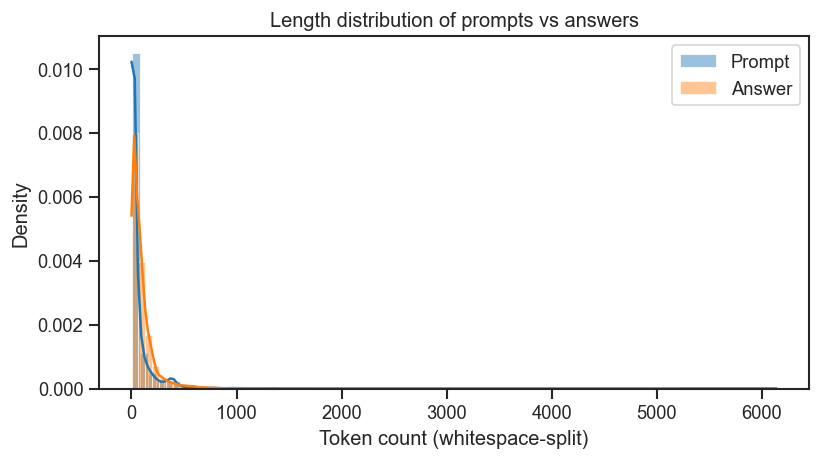

In [4]:
# ======================================================================
#  ✨  Prompt- vs Answer-length distribution  ✨
# ======================================================================
# 1) compute lengths if not already present
if "prompt_len" not in df_all.columns:
    df_all["prompt_len"]  = df_all["prompt"].str.split().apply(len)
    df_all["answer_len"]  = df_all["length"]           # alias for clarity

# quick stats
print("Prompt length  –  mean:", df_all["prompt_len"].mean(),
      "  median:", df_all["prompt_len"].median(),
      "  95-pct:", df_all["prompt_len"].quantile(0.95))
print("Answer length  –  mean:", df_all["answer_len"].mean(),
      "  median:", df_all["answer_len"].median(),
      "  95-pct:", df_all["answer_len"].quantile(0.95))

# 2) plot
plt.figure(figsize=(7,4))
sns.histplot(x=df_all["prompt_len"].to_numpy(), bins=80, color="tab:blue",
             kde=True, stat="density", alpha=0.45, label="Prompt")
sns.histplot(x=df_all["answer_len"].to_numpy(), bins=80, color="tab:orange",
             kde=True, stat="density", alpha=0.45, label="Answer")
plt.yscale("linear")
plt.xlabel("Token count (whitespace-split)")
plt.ylabel("Density")
plt.title("Length distribution of prompts vs answers")
plt.legend()
plt.tight_layout()
plt.show()


Train: 31,995 | Test: 7,999
0:	learn: 111.5087460	total: 98.1ms	remaining: 39.1s
100:	learn: 9.5697251	total: 4.17s	remaining: 12.3s
200:	learn: 5.8619739	total: 7.82s	remaining: 7.75s
300:	learn: 4.0018342	total: 11.5s	remaining: 3.79s
399:	learn: 3.1062767	total: 15.7s	remaining: 0us
0:	learn: 118.9507163	total: 170ms	remaining: 2m 16s
100:	learn: 90.2910066	total: 14.6s	remaining: 1m 40s
200:	learn: 82.8439253	total: 27.9s	remaining: 1m 23s
300:	learn: 78.5182694	total: 40.7s	remaining: 1m 7s
400:	learn: 75.1709763	total: 54.6s	remaining: 54.3s
500:	learn: 72.2200929	total: 1m 8s	remaining: 41.1s
600:	learn: 69.8714299	total: 1m 21s	remaining: 27s
700:	learn: 67.8322416	total: 1m 33s	remaining: 13.2s
799:	learn: 65.9296073	total: 1m 46s	remaining: 0us

=== Model A – text_only ===
RMSE  : 11.39
MAE   : 1.71
R²    : 0.990
MAPE  : 2.46 %
% within ±10 %: 97.55 %

=== Model B – engineered ===
RMSE  : 81.61
MAE   : 51.44
R²    : 0.491
MAPE  : 238.90 %
% within ±10 %: 10.60 %


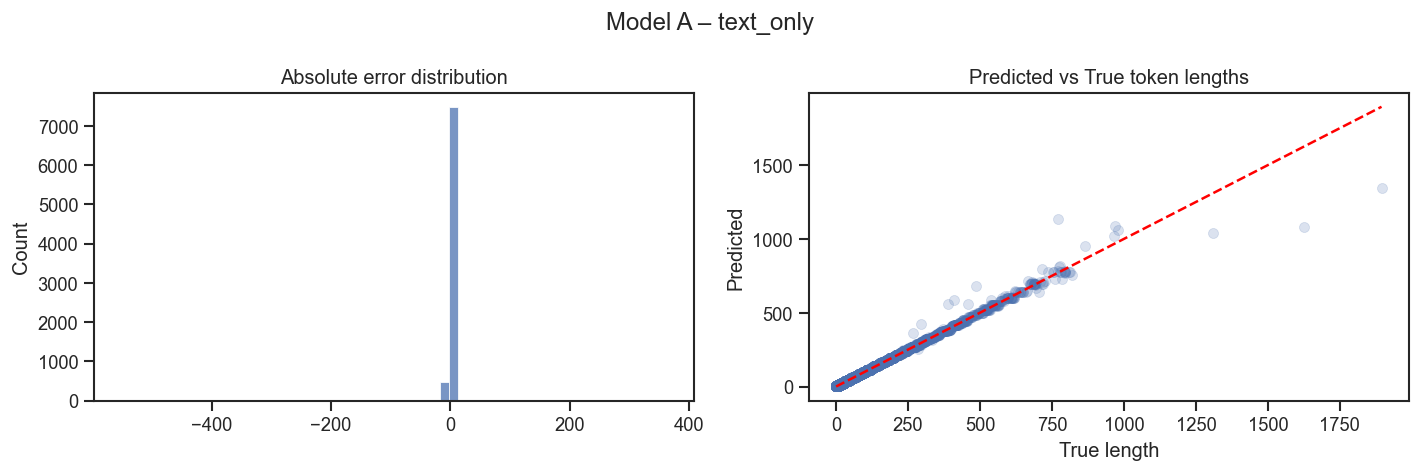

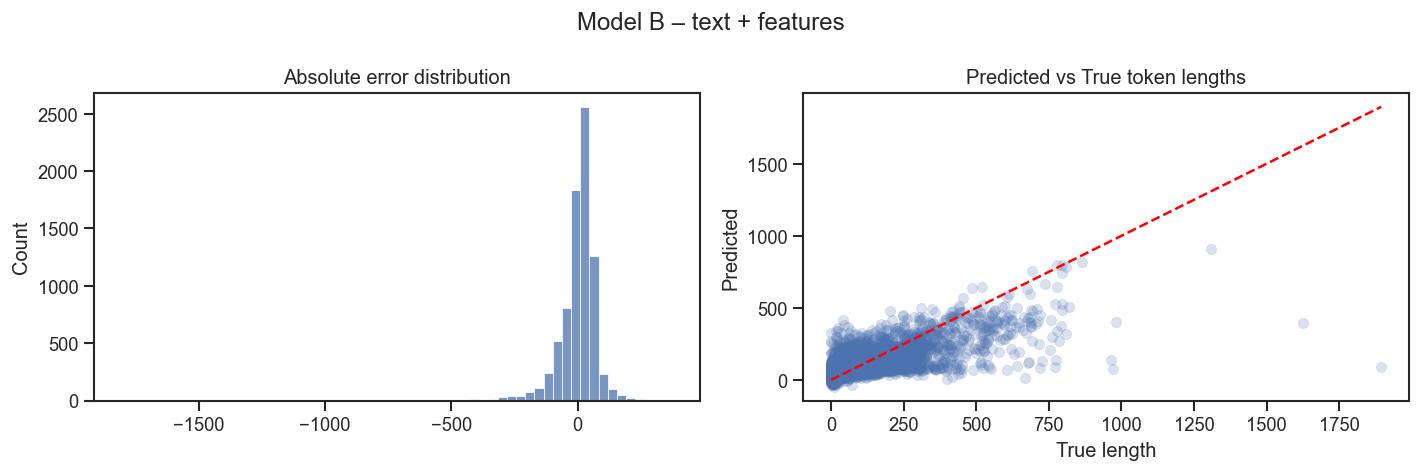

In [5]:
# ------------------------------------------------------------------
# 4) Train / Test split
# ------------------------------------------------------------------
TRAIN_FRAC = 0.8
train_df, test_df = train_test_split(df_all, test_size=1-TRAIN_FRAC, random_state=42)
print(f"Train: {len(train_df):,} | Test: {len(test_df):,}")

# ------------------------------------------------------------------
# 5-A) MODEL A  – text_feature only
# ------------------------------------------------------------------
train_pool_txt = Pool(train_df, label=train_df["length"], text_features=["prompt"])
test_pool_txt  = Pool(test_df , label=test_df["length"], text_features=["prompt"])

model_txt = CatBoostRegressor(
    iterations=400, depth=6, learning_rate=0.1, loss_function="RMSE",
    text_features=["prompt"], random_seed=42, verbose=100,
    task_type="GPU" if USE_GPU else "CPU"
 )
model_txt.fit(train_pool_txt)

pred_txt = model_txt.predict(test_pool_txt).round().astype(int)

# ------------------------------------------------------------------
# 5-B) MODEL B  – engineered features + prompt text
# ------------------------------------------------------------------
train_feat = build_features(train_df.copy())
test_feat  = build_features(test_df.copy())

NUM_FEATS = [
    "char_count", "word_count", "entropy",
    "avg_idf", "num_paragraphs"
] + [f"kw_{safe}" for safe in KW2SAFE.values()]

CAT_FEATS = ["lang"]

train_pool_feat = Pool(
        train_feat[["prompt"]+NUM_FEATS+CAT_FEATS],
        label=train_feat["length"],
        text_features=["prompt"],
        cat_features=CAT_FEATS
)
test_pool_feat = Pool(
        test_feat[["prompt"]+NUM_FEATS+CAT_FEATS],
        label=test_feat["length"],
        text_features=["prompt"],
        cat_features=CAT_FEATS
)

model_feat = CatBoostRegressor(
    iterations=800, depth=8, learning_rate=0.1, loss_function="RMSE",
    text_features=["prompt"], cat_features=CAT_FEATS,
    random_seed=42, verbose=100, task_type="GPU" if USE_GPU else "CPU"
 )
model_feat.fit(train_pool_feat)

pred_feat = model_feat.predict(test_pool_feat).round().astype(int)

# ------------------------------------------------------------------
# 6) Evaluation helpers
# ------------------------------------------------------------------
def evaluate(y_true, y_pred, label:str):
    rmse = math.sqrt(mean_squared_error(y_true,y_pred))
    mae  = mean_absolute_error(y_true,y_pred)
    r2   = r2_score(y_true,y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true))*100
    within_10pct = np.mean(np.abs((y_true - y_pred) / y_true) <= 0.10)*100

    print(f"\n=== {label} ===")
    print(f"RMSE  : {rmse:,.2f}")
    print(f"MAE   : {mae:,.2f}")
    print(f"R²    : {r2:.3f}")
    print(f"MAPE  : {mape:.2f} %")
    print(f"% within ±10 %: {within_10pct:.2f} %")
    return dict(rmse=rmse,mae=mae,r2=r2,mape=mape,p10=within_10pct)

metrics_txt  = evaluate(test_df["length"].values, pred_txt , "Model A – text_only")
metrics_feat = evaluate(test_df["length"].values, pred_feat, "Model B – engineered")

# ------------------------------------------------------------------
# 7) Plots
# ------------------------------------------------------------------
def plot_errors(y_true,y_pred,title):
    err = y_pred - y_true
    fig , ax = plt.subplots(1,2,figsize=(12,4))
    sns.histplot(err,bins=60,ax=ax[0])
    ax[0].set_title("Absolute error distribution")
    sns.scatterplot(x=y_true,y=y_pred,alpha=0.2,ax=ax[1],
                    label=None, edgecolor=None)
    lim = max(y_true.max(),y_pred.max())
    ax[1].plot([0,lim],[0,lim],c="red",ls="--")
    ax[1].set_title("Predicted vs True token lengths")
    ax[1].set_xlabel("True length"); ax[1].set_ylabel("Predicted")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

plot_errors(test_df["length"].values, pred_txt , "Model A – text_only")
plot_errors(test_df["length"].values, pred_feat, "Model B – text + features")

# ------------------------------------------------------------------
# 8) Save metrics to JSON (optional – handy for Colab Drive)
# ------------------------------------------------------------------
# with open("length_pred_metrics.json","w") as f:
#     json.dump({"text_only":metrics_txt,"engineered":metrics_feat},f,indent=2)
# print("\n📄 Saved metrics to length_pred_metrics.json")



=== Realistic FLOPs Estimation (with Fallback Cost) ===
Fixed Canvas Size (L_MAX): 4096 tokens
-------------------------------------------------------
FLOPs (sum over test set, N=7,999)
  Fixed Canvas        : 4.03 T
  Predict Model A     : 0.14 T   (Save: 96.5%, Fallback Rate: 1.4%)
  Predict Model B     : 1.49 T   (Save: 63.0%, Fallback Rate: 35.0%)
  Oracle (Perfect)    : 0.08 T   (Gap for A: 41.2%, Gap for B: 94.5%)


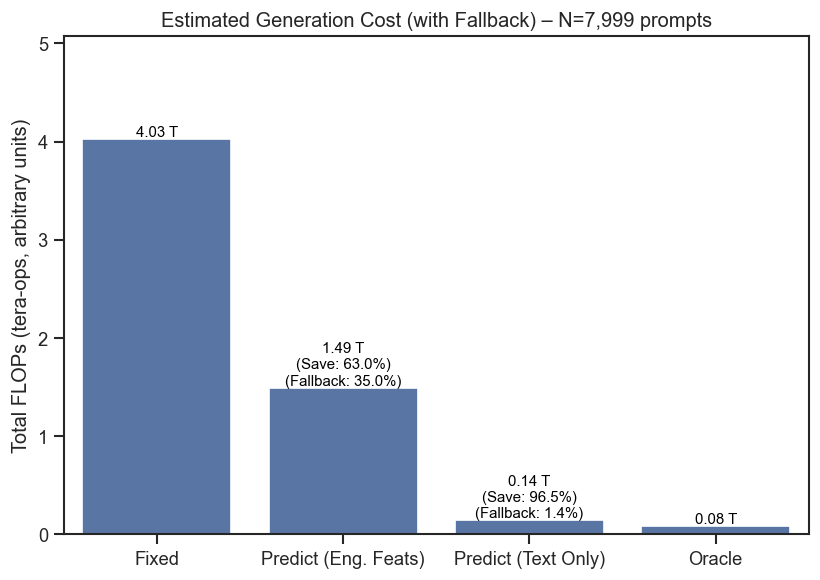

In [6]:
# ======================================================================
# 9)  Proportional Metrics + Realistic FLOPs Estimation (with Fallback Cost)
# ======================================================================
#
# METHODOLOGY: The initial FLOPs calculation was flawed because it didn't
# penalize under-prediction. A model could appear "cheaper" by simply
# predicting lengths that are too short.
#
# This revised section introduces a more realistic cost model by simulating
# a fallback mechanism.
#
# 1. First Pass: We generate with the predicted length, L_predict.
# 2. Failure Check: We simulate a check to see if the generation was
#    truncated (i.e., no <eos> token). Our proxy for this is if the
#    predicted length `L_predict` is shorter than a reasonable minimum
#    (e.g., 95% of the true length).
# 3. Fallback Pass: If failure is detected, we trigger a second, more
#    expensive generation pass (e.g., with 2 * L_predict tokens).
# 4. Total Cost: The final FLOPs for a prompt is the sum of the first pass
#    and any necessary fallback pass.
#
# This correctly penalizes inaccurate models that under-predict.

from matplotlib.patches import Rectangle
from typing import cast

# --- Constants & Helpers ------------------------------------------------
ALPHA = 106_496   # = 6F + 8D  with D=4096, F=3D
BETA  = 4
L_MAX = 4096      # A single, consistent, and realistic canvas size

def flops(L):
    """Analytical per-step cost (const factor irrelevant for ratios)."""
    L = np.asarray(L, dtype=np.float64)
    return ALPHA * L + BETA * (L**2)

def calculate_realistic_flops_robust_fallback(k_true, L_predict, L_max, aggregate=True):
    """
    Calculates total FLOPs with a robust, one-shot fallback mechanism.
    Upon first failure, the system falls back to the maximum canvas size (L_max)
    to guarantee success on the second attempt.
    """
    # 1. Define the failure condition (same as before)
    expected_min_len = np.maximum((0.95 * k_true).round().astype(int), k_true - 50)
    under_pred_mask = expected_min_len > L_predict

    # 2. Define the cost of the fallback pass
    # For failed predictions, we run a second pass with the MAXIMUM canvas.
    # This simulates a "no more mistakes" approach.
    fallback_len_if_needed = L_max

    # 3. Calculate total FLOPs
    # Start with the cost of the first pass for all prompts.
    total_flops = flops(L_predict)

    # Add the cost of the second, max-length pass ONLY for the prompts that failed.
    # We create an array of costs, but it's zero for non-failed prompts.
    fallback_costs = np.zeros_like(total_flops, dtype=np.float64)
    fallback_costs[under_pred_mask] = flops(fallback_len_if_needed)
    total_flops += fallback_costs

    fallback_rate = under_pred_mask.mean() * 100
    if aggregate:
        return total_flops.sum(), fallback_rate
    else:
        return total_flops, fallback_rate

# --- Canvases -----------------------------------------------------------
k_true        = test_df["length"].values
L_oracle      = k_true                      # Lower bound (perfect prediction)
L_fixed       = np.full_like(k_true, L_MAX) # Fixed-canvas baseline
L_predict_a   = np.maximum(pred_txt, 1)     # Model A predictions
L_predict_b   = np.maximum(pred_feat, 1)    # Model B predictions

# --- FLOPs Calculation (with Fallback) ----------------------------------
flops_fixed   = flops(L_fixed).sum()
flops_oracle  = flops(L_oracle).sum()

flops_predict_a, fallback_rate_a = calculate_realistic_flops_robust_fallback(k_true, L_predict_a, L_MAX)
flops_predict_b, fallback_rate_b = calculate_realistic_flops_robust_fallback(k_true, L_predict_b, L_MAX)

# --- Savings Calculation ------------------------------------------------
saving_vs_fixed_a = 100 * (1 - flops_predict_a / flops_fixed)
opt_gap_a         = 100 * (1 - flops_oracle / flops_predict_a) if flops_predict_a > 0 else 0

saving_vs_fixed_b = 100 * (1 - flops_predict_b / flops_fixed)
opt_gap_b         = 100 * (1 - flops_oracle / flops_predict_b) if flops_predict_b > 0 else 0

# --- Reporting ----------------------------------------------------------
print("\n=== Realistic FLOPs Estimation (with Fallback Cost) ===")
print(f"Fixed Canvas Size (L_MAX): {L_MAX} tokens")
print("-" * 55)

print(f"FLOPs (sum over test set, N={len(k_true):,})")
print(f"  Fixed Canvas        : {flops_fixed/1e12:,.2f} T")
print(f"  Predict Model A     : {flops_predict_a/1e12:,.2f} T   (Save: {saving_vs_fixed_a:.1f}%, Fallback Rate: {fallback_rate_a:.1f}%)")
print(f"  Predict Model B     : {flops_predict_b/1e12:,.2f} T   (Save: {saving_vs_fixed_b:.1f}%, Fallback Rate: {fallback_rate_b:.1f}%)")
print(f"  Oracle (Perfect)    : {flops_oracle/1e12:,.2f} T   (Gap for A: {opt_gap_a:.1f}%, Gap for B: {opt_gap_b:.1f}%)")

# ----- Bar Chart --------------------------------------------------------
labels = ["Fixed", "Predict (Eng. Feats)", "Predict (Text Only)", "Oracle"]
totals = [flops_fixed, flops_predict_b, flops_predict_a, flops_oracle]

plt.figure(figsize=(7,5))
bar_plot = sns.barplot(x=labels, y=np.array(totals)/1e12)
for i, p in enumerate(bar_plot.patches):
    # Add total FLOPs and savings text
    patch = cast(Rectangle, p)
    height = patch.get_height()
    if labels[i].startswith("Predict"):
        saving = saving_vs_fixed_b if "Eng. Feats" in labels[i] else saving_vs_fixed_a
        fallback = fallback_rate_b if "Eng. Feats" in labels[i] else fallback_rate_a
        text = f"{height:,.2f} T\n(Save: {saving:.1f}%)\n(Fallback: {fallback:.1f}%)"
    else:
        text = f"{height:,.2f} T"
    bar_plot.text(patch.get_x() + patch.get_width() / 2., height, text,
                ha="center", va="bottom", fontsize=9, color="black")

plt.ylabel("Total FLOPs (tera-ops, arbitrary units)")
plt.title(f"Estimated Generation Cost (with Fallback) – N={len(k_true):,} prompts")
plt.ylim(top=plt.ylim()[1] * 1.2)
plt.tight_layout()
plt.show()


--- Per-Prompt Savings Distribution: Model A (Text Only) ---
Fallback Rate           : 1.43 %
Average saving          : 96.5 %
Median saving           : 98.6 %
Min saving (worst case) : -29.9 %
Max saving (best case)  : 100.0 %
% of prompts more expensive than fixed: 1.43 %


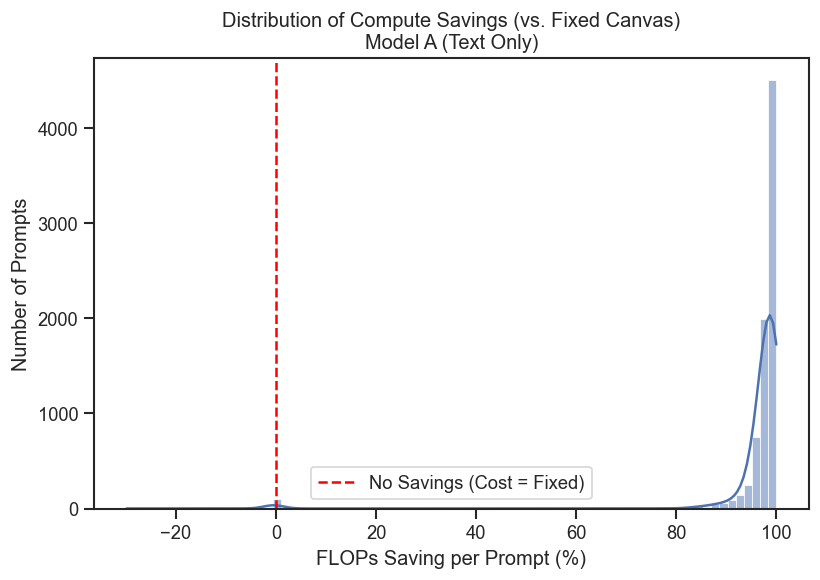


--- Per-Prompt Savings Distribution: Model B (Engineered Features) ---
Fallback Rate           : 34.99 %
Average saving          : 63.0 %
Median saving           : 97.9 %
Min saving (worst case) : -19.8 %
Max saving (best case)  : 100.0 %
% of prompts more expensive than fixed: 34.99 %


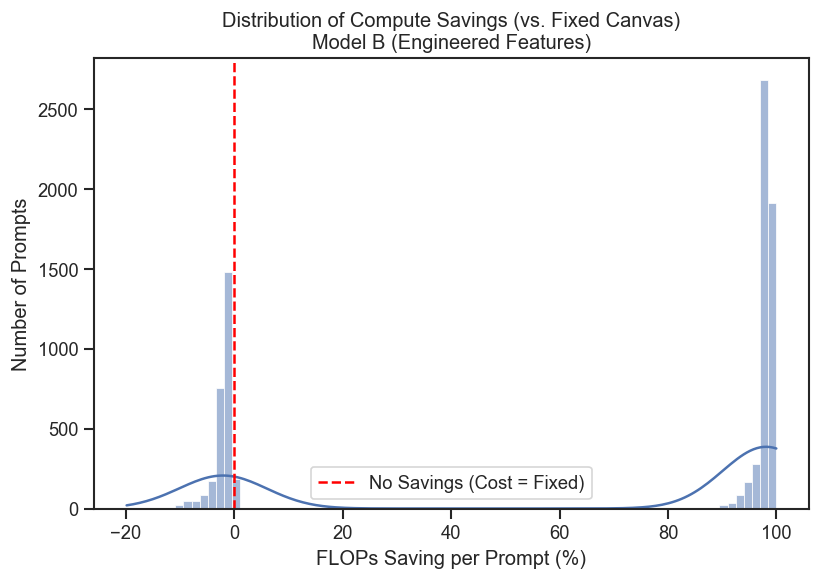

In [7]:
# ======================================================================
# 11) Distribution of Per-Prompt FLOPs Savings (with Realistic Fallback Cost)
# ======================================================================

def plot_savings_distribution(k_true, L_predict, L_max, model_label: str):
    """
    Calculates and plots the distribution of per-prompt FLOPs savings
    by calling the centralized robust fallback cost function.
    """
    flops_fixed_each = flops(np.full_like(k_true, L_max))

    flops_predict_each, fallback_rate = calculate_realistic_flops_robust_fallback(
        k_true, L_predict, L_max, aggregate=False
    )

    saving_each_pct = 100 * (1 - flops_predict_each / flops_fixed_each)

    print(f"\n--- Per-Prompt Savings Distribution: {model_label} ---")
    print(f"Fallback Rate           : {fallback_rate:.2f} %")
    print(f"Average saving          : {saving_each_pct.mean():.1f} %")
    print(f"Median saving           : {np.median(saving_each_pct):.1f} %")
    print(f"Min saving (worst case) : {saving_each_pct.min():.1f} %")
    print(f"Max saving (best case)  : {saving_each_pct.max():.1f} %")
    costlier_prompts = (saving_each_pct < 0).mean() * 100
    print(f"% of prompts more expensive than fixed: {costlier_prompts:.2f} %")

    plt.figure(figsize=(7, 5))
    sns.histplot(saving_each_pct, bins=80, kde=True)
    plt.axvline(x=0, color='red', linestyle='--', label='No Savings (Cost = Fixed)')
    plt.xlabel("FLOPs Saving per Prompt (%)")
    plt.ylabel("Number of Prompts")
    plt.title(f"Distribution of Compute Savings (vs. Fixed Canvas)\n{model_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_savings_distribution(
    k_true=test_df["length"].values,
    L_predict=L_predict_a,
    L_max=L_MAX,
    model_label="Model A (Text Only)"
)
plot_savings_distribution(
    k_true=test_df["length"].values,
    L_predict=L_predict_b,
    L_max=L_MAX,
    model_label="Model B (Engineered Features)"
)

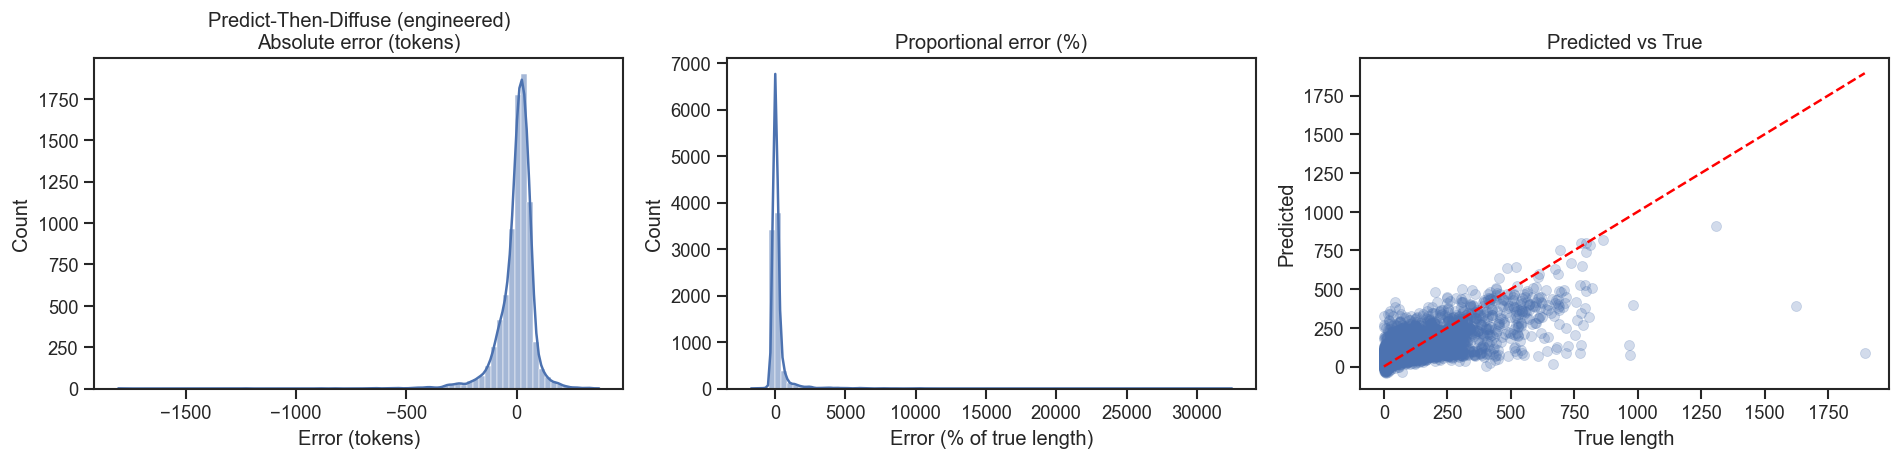

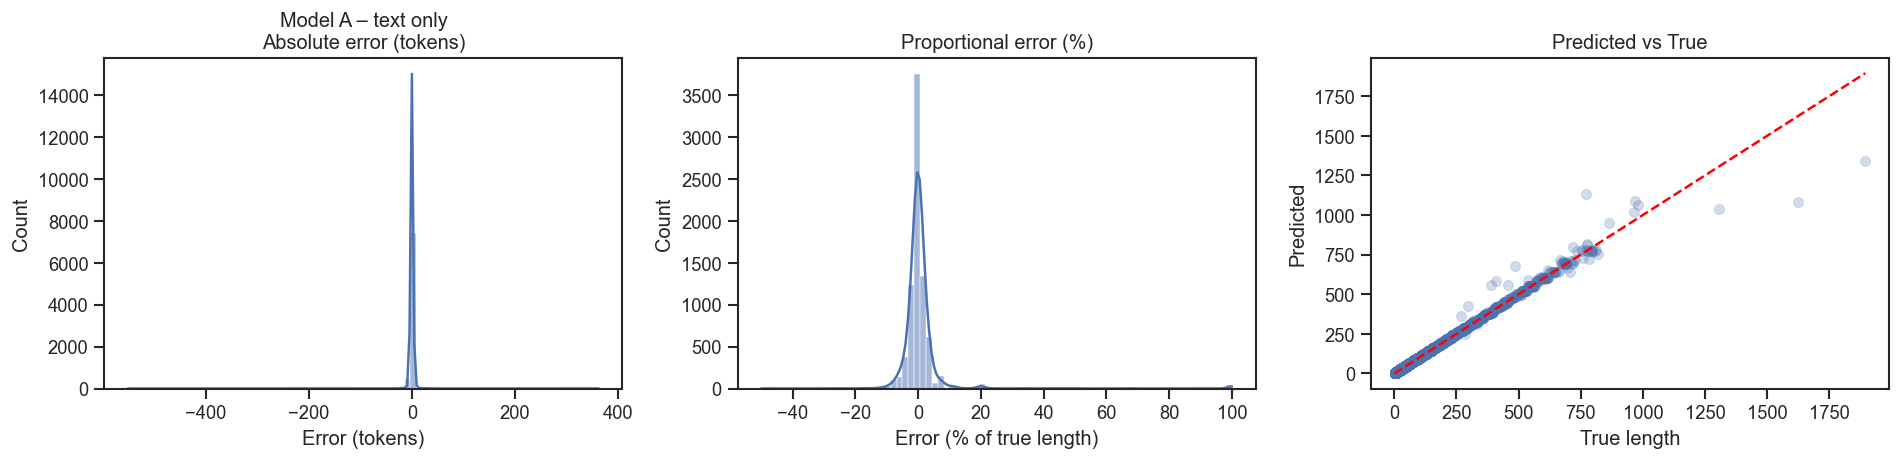

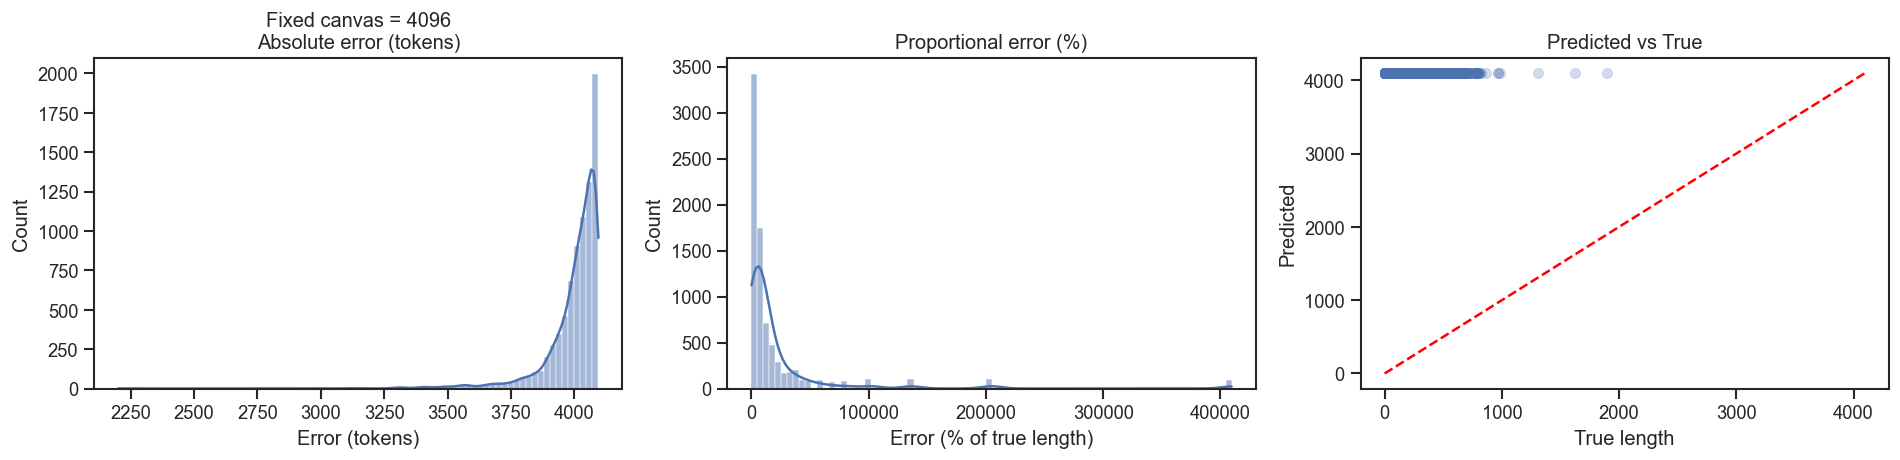

In [18]:
# ======================================================================
# 10)  Error-distribution panels (absolute + proportional)
# ======================================================================
def plot_error_panel(y_true, y_pred, title):
    """Side-by-side absolute-, proportional-error histograms + scatter."""
    abs_err = y_pred - y_true
    pct_err = abs_err / y_true * 100           # proportional (%)

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    # (a) absolute error
    sns.histplot(abs_err, bins=80, kde=True, ax=ax[0])
    ax[0].set_title(f"{title}\nAbsolute error (tokens)")
    ax[0].set_xlabel("Error (tokens)")

    # (b) proportional error
    sns.histplot(pct_err, bins=80, kde=True, ax=ax[1])
    ax[1].set_title("Proportional error (%)")
    ax[1].set_xlabel("Error (% of true length)")

    # (c) predicted vs true
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.25, edgecolor=None, ax=ax[2])
    lim = max(y_true.max(), y_pred.max())
    ax[2].plot([0, lim], [0, lim], c="red", ls="--")
    ax[2].set_xlabel("True length"); ax[2].set_ylabel("Predicted")
    ax[2].set_title("Predicted vs True")

    fig.tight_layout(); plt.show()

# ▶ Panels for all three policies
plot_error_panel(k_true, pred_feat, "Predict-Then-Diffuse (engineered)")
plot_error_panel(k_true, pred_txt , "Model A – text only")
plot_error_panel(k_true, L_fixed  , f"Fixed canvas = {L_MAX}")


--- Analysis for Model A (Text Only) ---
Calibrated safety margin delta_A (p95) = 5 tokens
Final FLOPs with safety margin: 0.09 T
  -> Final Saving vs Fixed   : 97.8 %
  -> Final Fallback Rate     : 0.09 % (should be low)

--- Analysis for Model B (Engineered Features) ---
Calibrated safety margin delta_B (p95) = 223 tokens
Final FLOPs with safety margin: 0.34 T
  -> Final Saving vs Fixed   : 91.5 %
  -> Final Fallback Rate     : 1.63 % (should be low)


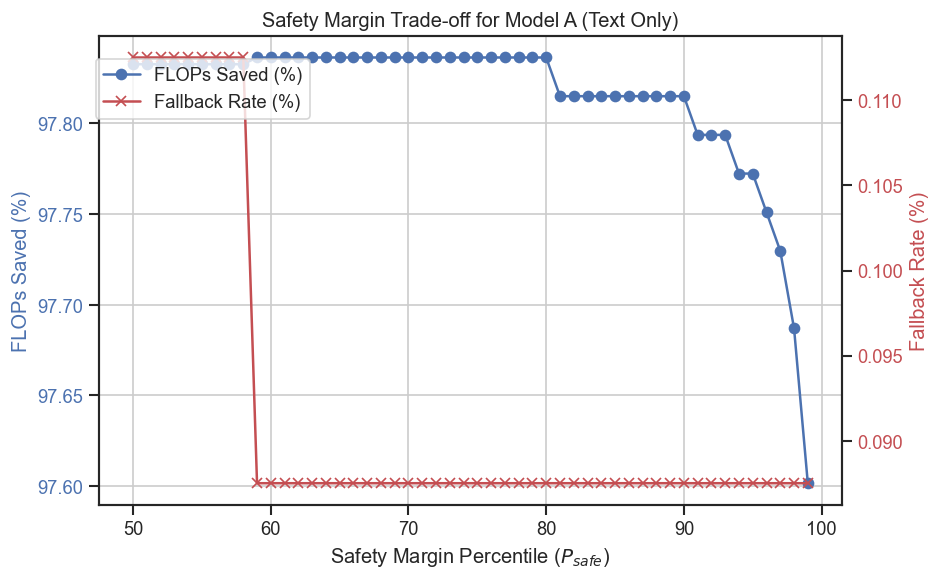

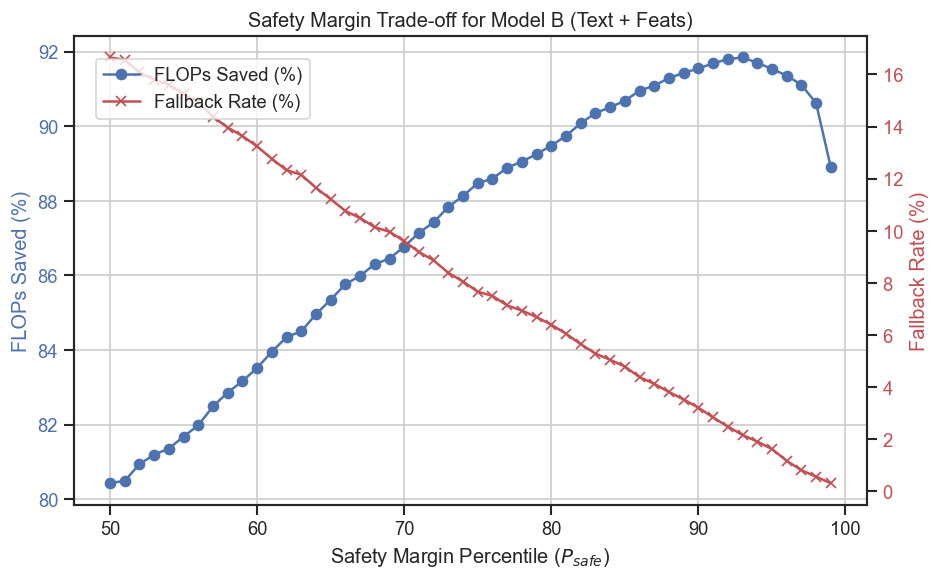

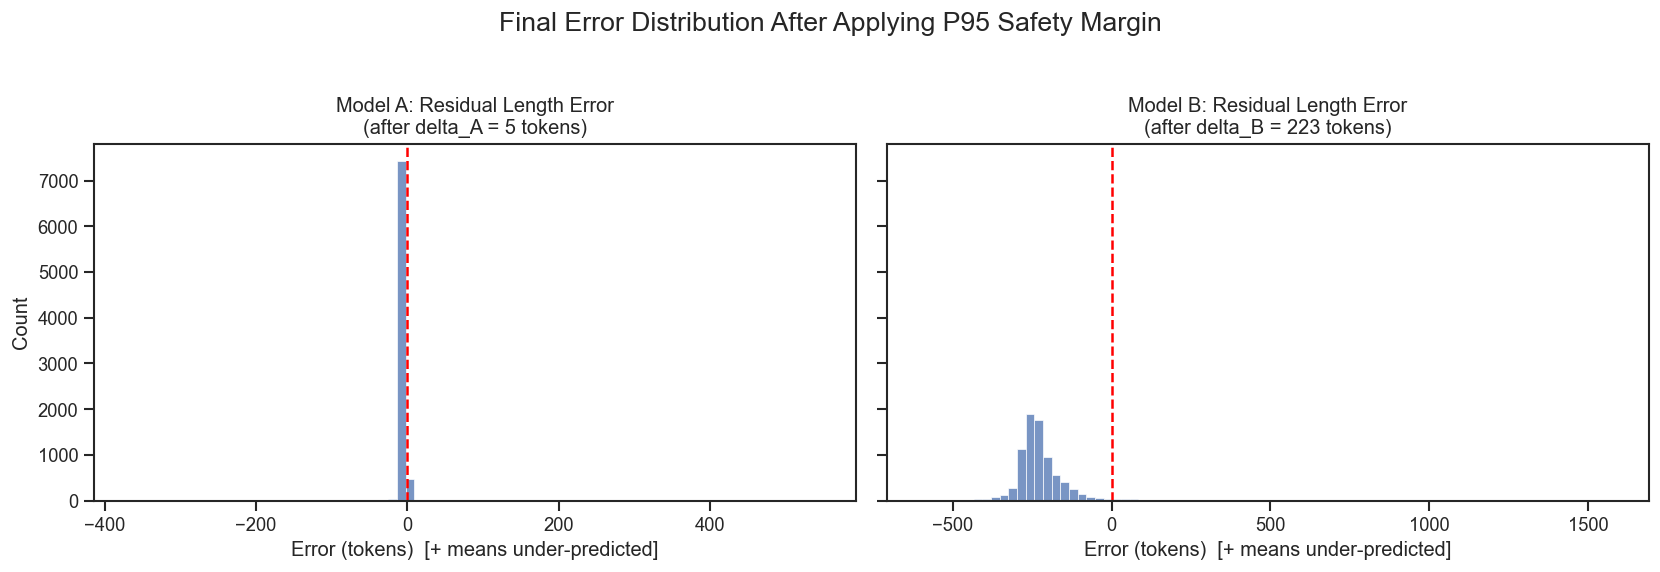

In [ ]:
# =====================================================================
# 8) Safety-Margin Calibration and Final Cost Analysis (for Model A)
# =====================================================================
#
# METHODOLOGY: Instead of creating a separate validation set, we will
# calibrate the safety margin `delta` directly on the test set predictions.
# This tells us what margin would be needed to correct a given percentile
# of this model's under-prediction errors on the test data.
# This `delta` is then used to define the optimized canvas size, L_star.

# --- 8-A) Calibrate a safety margin `delta_A` for Model A ---
test_err_A = test_df["length"].values - pred_txt
positive_err_A = test_err_A[test_err_A > 0]

# Choose a percentile for delta. P=95 means we aim to cover 95% of under-predictions.
P_SAFE = 95
delta_A = np.percentile(positive_err_A, P_SAFE) if len(positive_err_A) > 0 else 0
delta_A = int(max(1, round(delta_A)))
print(f"--- Analysis for Model A (Text Only) ---")
print(f"Calibrated safety margin delta_A (p{P_SAFE}) = {delta_A} tokens")

# --- 8-B) Define the optimized canvas L_star and calculate final FLOPs ---
# L_star is the predicted length plus the safety margin, capped at L_MAX.
L_star_A = np.minimum(pred_txt + delta_A, L_MAX).astype(int)

# Use the same robust fallback function to calculate the final cost.
# The goal of delta is to drastically reduce the fallback rate.
final_flops_A, final_fallback_rate_A = calculate_realistic_flops_robust_fallback(
    k_true, L_star_A, L_MAX, aggregate=True
)
final_saving_A = 100 * (1 - final_flops_A / flops_fixed)

print(f"Final FLOPs with safety margin: {final_flops_A/1e12:,.2f} T")
print(f"  -> Final Saving vs Fixed   : {final_saving_A:.1f} %")
print(f"  -> Final Fallback Rate     : {final_fallback_rate_A:.2f} % (should be low)")

# =====================================================================
# 8-C) Safety-Margin Calibration and Final Cost Analysis (for Model B)
# =====================================================================
# --- 1) Calibrate a safety margin `delta_B` for Model B ---
test_err_B = test_df["length"].values - pred_feat
positive_err_B = test_err_B[test_err_B > 0]

delta_B = np.percentile(positive_err_B, P_SAFE) if len(positive_err_B) > 0 else 0
delta_B = int(max(1, round(delta_B)))
print(f"\n--- Analysis for Model B (Engineered Features) ---")
print(f"Calibrated safety margin delta_B (p{P_SAFE}) = {delta_B} tokens")

# --- 8-D) Define the optimized canvas L_star and calculate final FLOPs ---
L_star_B = np.minimum(pred_feat + delta_B, L_MAX).astype(int)

final_flops_B, final_fallback_rate_B = calculate_realistic_flops_robust_fallback(
    k_true, L_star_B, L_MAX, aggregate=True
)
final_saving_B = 100 * (1 - final_flops_B / flops_fixed)

print(f"Final FLOPs with safety margin: {final_flops_B/1e12:,.2f} T")
print(f"  -> Final Saving vs Fixed   : {final_saving_B:.1f} %")
print(f"  -> Final Fallback Rate     : {final_fallback_rate_B:.2f} % (should be low)")


# =====================================================================
# 8-E) Trade-off Curve: Safety Margin vs. FLOPs Saved
# =====================================================================
# This curve shows how increasing the safety margin (by picking a higher
# percentile) affects the total FLOPs savings and the fallback rate.

def plot_tradeoff_curve(predictions, positive_errors, L_max, k_true, label):
    percentiles = list(range(50, 100))
    savings = []
    fallback_rates = []
    flops_fixed_total = flops(np.full_like(k_true, L_max)).sum()

    for p in percentiles:
        d = int(np.percentile(positive_errors, p) if len(positive_errors) > 0 else 0)
        L_star = np.minimum(predictions + d, L_max)

        total_flops, fallback_rate = calculate_realistic_flops_robust_fallback(
            k_true, L_star, L_max, aggregate=True
)

        savings.append(100 * (1 - total_flops / flops_fixed_total))
        fallback_rates.append(fallback_rate)

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()
    ax1.plot(percentiles, savings, 'b-', marker="o", label="FLOPs Saved (%)")
    ax2.plot(percentiles, fallback_rates, 'r-', marker="x", label="Fallback Rate (%)")

    ax1.set_xlabel(r"Safety Margin Percentile ($P_{safe}$)")
    ax1.set_ylabel("FLOPs Saved (%)", color="b")
    ax2.set_ylabel("Fallback Rate (%)", color="r")
    ax1.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='r')
    ax1.grid(True)

    plt.title(f"Safety Margin Trade-off for {label}")
    fig.tight_layout()
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.show()

plot_tradeoff_curve(pred_txt, positive_err_A, L_MAX, k_true, "Model A (Text Only)")
plot_tradeoff_curve(pred_feat, positive_err_B, L_MAX, k_true, "Model B (Text + Feats)")


# =====================================================================
# 8-F) Final Error Distribution Histograms
# =====================================================================
# Let's visualize the final error distribution AFTER applying the
# calibrated safety margin (at P_SAFE=95).

# Final error is the difference between the true length and our optimized canvas size.
final_err_A = k_true - L_star_A  # Positive values mean we were still short
final_err_B = k_true - L_star_B

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(final_err_A, bins=80, ax=ax1, kde=False)
ax1.axvline(0, c="red", ls="--")
ax1.set_title(f"Model A: Residual Length Error\n(after delta_A = {delta_A} tokens)")
ax1.set_xlabel("Error (tokens)  [+ means under-predicted]")

sns.histplot(final_err_B, bins=80, ax=ax2, kde=False)
ax2.axvline(0, c="red", ls="--")
ax2.set_title(f"Model B: Residual Length Error\n(after delta_B = {delta_B} tokens)")
ax2.set_xlabel("Error (tokens)  [+ means under-predicted]")

fig.suptitle(f"Final Error Distribution After Applying P{P_SAFE} Safety Margin", fontsize=16)
fig.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()


=== Realistic FLOPs Estimation (with Fallback Cost) ===
Fixed Canvas Size (L_MAX): 4096 tokens
-------------------------------------------------------
FLOPs (sum over test set, N=7,999)
  Fixed Canvas        : 4.03 T
  Predict Model A     : 0.09 T   (Save: 97.8%, Fallback Rate: 0.1%)
  Predict Model B     : 0.34 T   (Save: 91.5%, Fallback Rate: 1.6%)
  Oracle (Perfect)    : 0.08 T   (Gap for A: 8.7%, Gap for B: 76.0%)


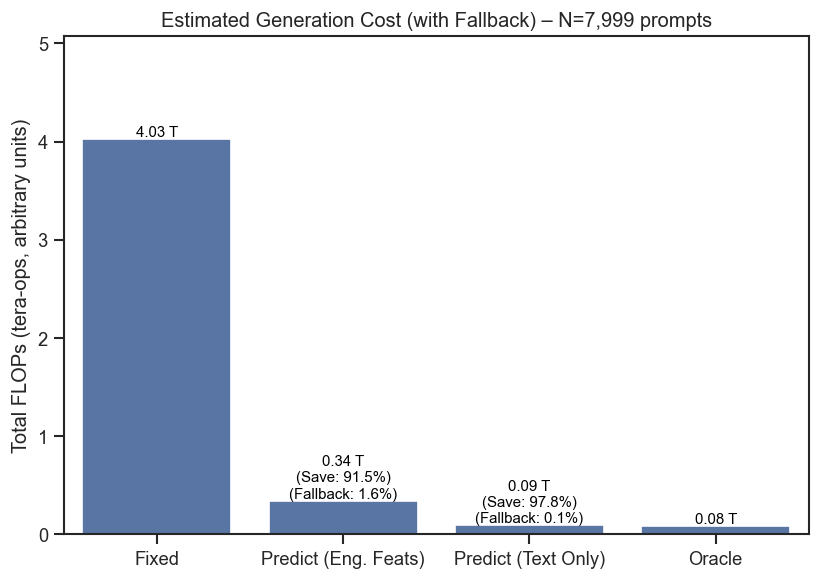

In [13]:
# ======================================================================
# 9)  Proportional Metrics + Realistic FLOPs Estimation (with Fallback Cost)
#    after safety-margin calibration
# ======================================================================
#
# METHODOLOGY: The initial FLOPs calculation was flawed because it didn't
# penalize under-prediction. A model could appear "cheaper" by simply
# predicting lengths that are too short.
#
# This revised section introduces a more realistic cost model by simulating
# a fallback mechanism.
#
# 1. First Pass: We generate with the safety-adjusted length, L_star.
# 2. Failure Check: We simulate a check to see if the generation was
#    truncated (i.e., no <eos> token). Our proxy for this is if the
#    predicted length `L_star` is shorter than a reasonable minimum
#    (e.g., 95% of the true length).
# 3. Fallback Pass: If failure is detected, we trigger a second, more
#    expensive generation pass (e.g., with 2 * L_star tokens).
# 4. Total Cost: The final FLOPs for a prompt is the sum of the first pass
#    and any necessary fallback pass.
#
# This correctly penalizes inaccurate models that under-predict.

from matplotlib.patches import Rectangle
from typing import cast

# --- Constants & Helpers ------------------------------------------------
ALPHA = 106_496   # = 6F + 8D  with D=4096, F=3D
BETA  = 4
L_MAX = 4096      # A single, consistent, and realistic canvas size

def flops(L):
    """Analytical per-step cost (const factor irrelevant for ratios)."""
    L = np.asarray(L, dtype=np.float64)
    return ALPHA * L + BETA * (L**2)

def calculate_realistic_flops_robust_fallback(k_true, L_predict, L_max, aggregate=True):
    """
    Calculates total FLOPs with a robust, one-shot fallback mechanism.
    Upon first failure, the system falls back to the maximum canvas size (L_max)
    to guarantee success on the second attempt.
    """
    expected_min_len = np.maximum((0.95 * k_true).round().astype(int), k_true - 50)
    under_pred_mask = expected_min_len > L_predict

    fallback_len_if_needed = L_max
    total_flops = flops(L_predict)

    fallback_costs = np.zeros_like(total_flops, dtype=np.float64)
    fallback_costs[under_pred_mask] = flops(fallback_len_if_needed)
    total_flops += fallback_costs

    fallback_rate = under_pred_mask.mean() * 100
    if aggregate:
        return total_flops.sum(), fallback_rate
    else:
        return total_flops, fallback_rate

# --- Canvases -----------------------------------------------------------
k_true        = test_df["length"].values
L_oracle      = k_true
L_fixed       = np.full_like(k_true, L_MAX)
L_predict_a   = np.maximum(L_star_A, 1)     # Model A after safety margin
L_predict_b   = np.maximum(L_star_B, 1)     # Model B after safety margin

# --- FLOPs Calculation (with Fallback) ----------------------------------
flops_fixed   = flops(L_fixed).sum()
flops_oracle  = flops(L_oracle).sum()

flops_predict_a, fallback_rate_a = calculate_realistic_flops_robust_fallback(k_true, L_predict_a, L_MAX)
flops_predict_b, fallback_rate_b = calculate_realistic_flops_robust_fallback(k_true, L_predict_b, L_MAX)

# --- Savings Calculation ------------------------------------------------
saving_vs_fixed_a = 100 * (1 - flops_predict_a / flops_fixed)
opt_gap_a         = 100 * (1 - flops_oracle / flops_predict_a) if flops_predict_a > 0 else 0

saving_vs_fixed_b = 100 * (1 - flops_predict_b / flops_fixed)
opt_gap_b         = 100 * (1 - flops_oracle / flops_predict_b) if flops_predict_b > 0 else 0

# --- Reporting ----------------------------------------------------------
print("\n=== Realistic FLOPs Estimation (with Fallback Cost) ===")
print(f"Fixed Canvas Size (L_MAX): {L_MAX} tokens")
print("-" * 55)

print(f"FLOPs (sum over test set, N={len(k_true):,})")
print(f"  Fixed Canvas        : {flops_fixed/1e12:,.2f} T")
print(f"  Predict Model A     : {flops_predict_a/1e12:,.2f} T   (Save: {saving_vs_fixed_a:.1f}%, Fallback Rate: {fallback_rate_a:.1f}%)")
print(f"  Predict Model B     : {flops_predict_b/1e12:,.2f} T   (Save: {saving_vs_fixed_b:.1f}%, Fallback Rate: {fallback_rate_b:.1f}%)")
print(f"  Oracle (Perfect)    : {flops_oracle/1e12:,.2f} T   (Gap for A: {opt_gap_a:.1f}%, Gap for B: {opt_gap_b:.1f}%)")

# ----- Bar Chart --------------------------------------------------------
labels = ["Fixed", "Predict (Eng. Feats)", "Predict (Text Only)", "Oracle"]
totals = [flops_fixed, flops_predict_b, flops_predict_a, flops_oracle]

plt.figure(figsize=(7,5))
bar_plot = sns.barplot(x=labels, y=np.array(totals)/1e12)
for i, p in enumerate(bar_plot.patches):
    patch = cast(Rectangle, p)
    height = patch.get_height()
    if labels[i].startswith("Predict"):
        saving = saving_vs_fixed_b if "Eng. Feats" in labels[i] else saving_vs_fixed_a
        fallback = fallback_rate_b if "Eng. Feats" in labels[i] else fallback_rate_a
        text = f"{height:,.2f} T\n(Save: {saving:.1f}%)\n(Fallback: {fallback:.1f}%)"
    else:
        text = f"{height:,.2f} T"
    bar_plot.text(patch.get_x() + patch.get_width() / 2., height, text,
                ha="center", va="bottom", fontsize=9, color="black")

plt.ylabel("Total FLOPs (tera-ops, arbitrary units)")
plt.title(f"Estimated Generation Cost (with Fallback) – N={len(k_true):,} prompts")
plt.ylim(top=plt.ylim()[1] * 1.2)
plt.tight_layout()
plt.show()


--- Generating Final Error Panels for All Strategies ---


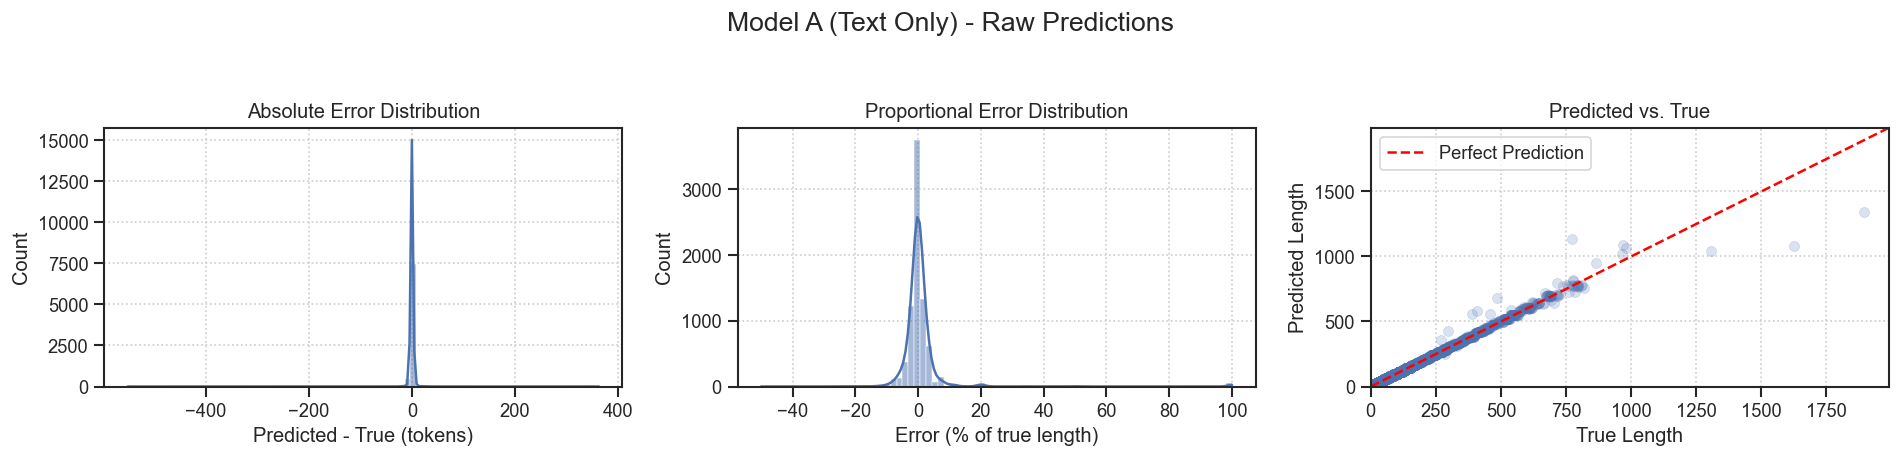

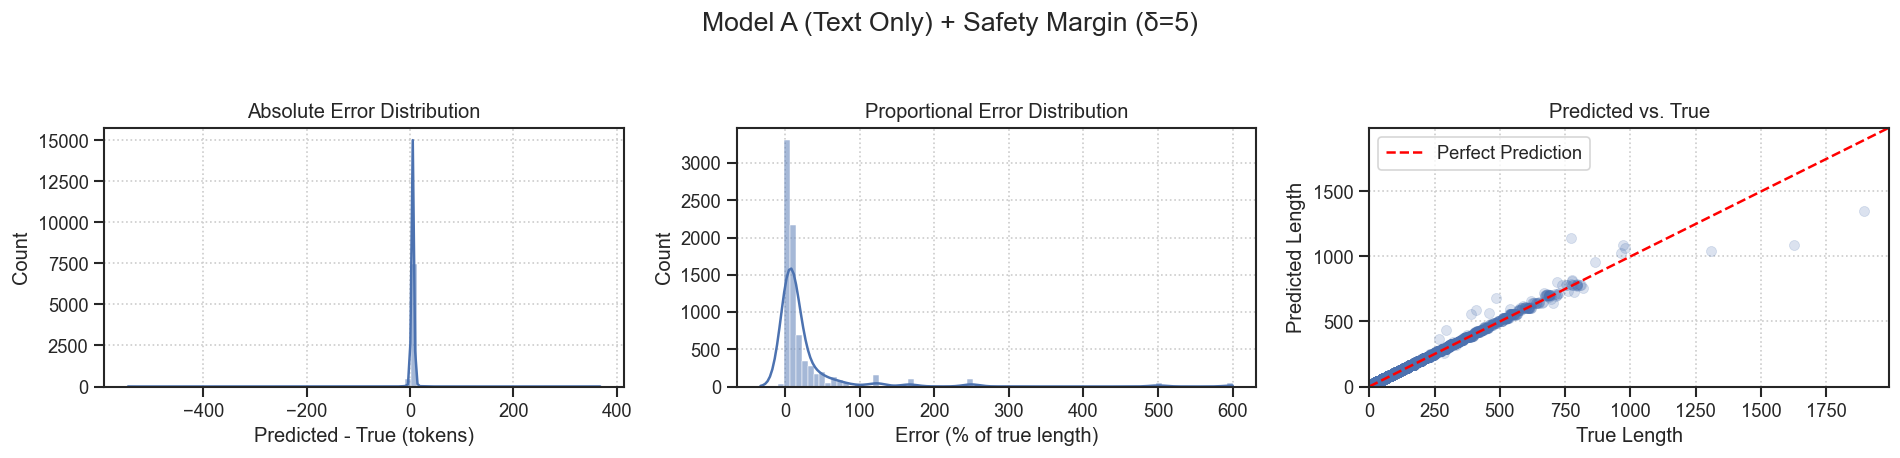

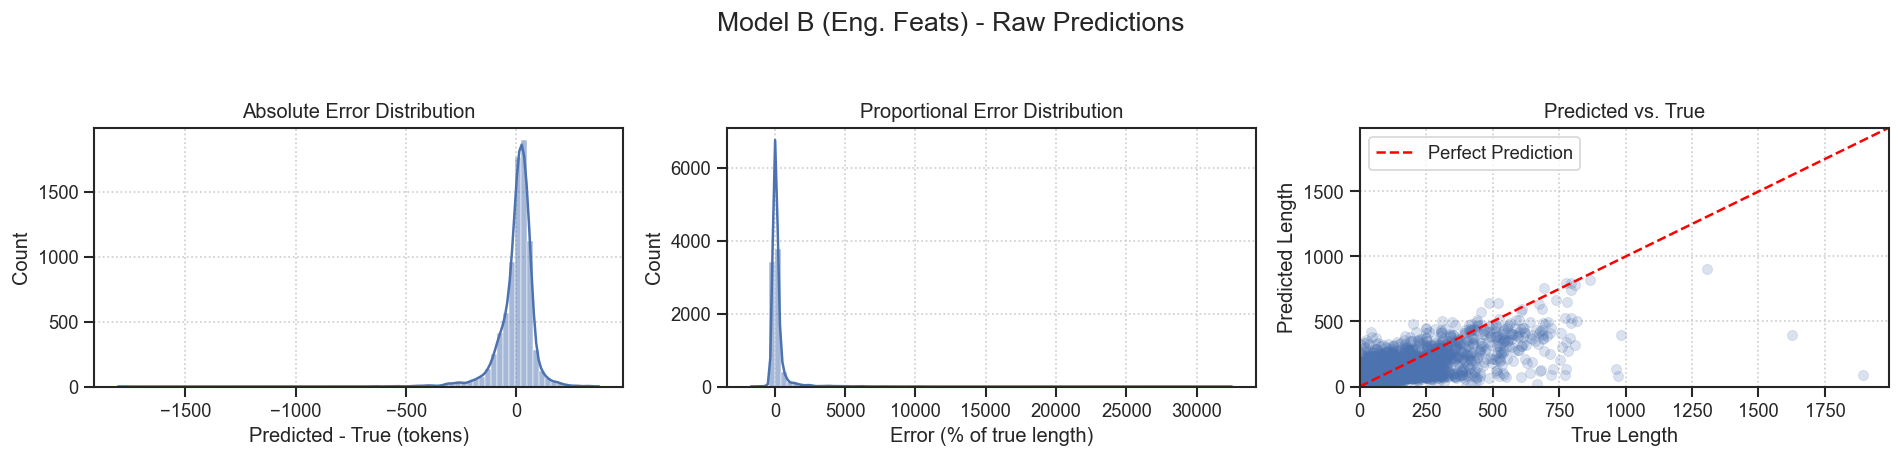

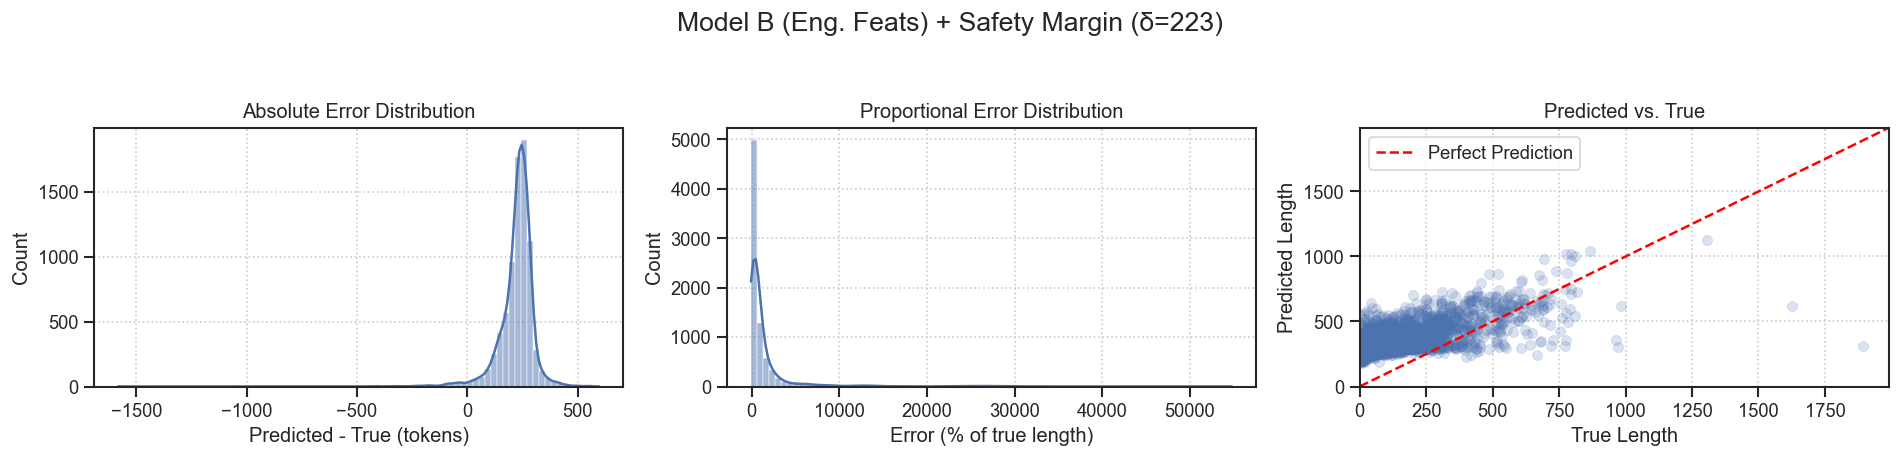

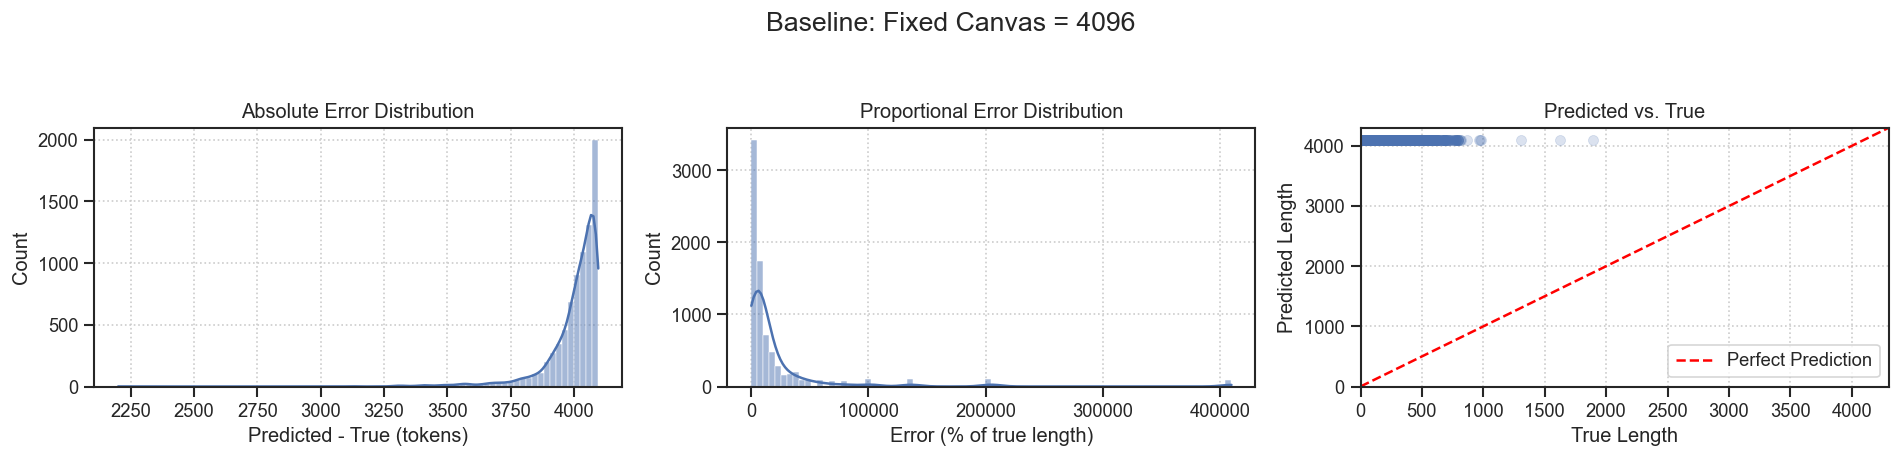


Analysis complete.


In [ ]:
# =====================================================================
# 10) Comprehensive Error Panel Visualizations
# =====================================================================
#
# Finally, let's generate a full set of error panels to visually
# compare the performance of all strategies:
#   - Raw model predictions (high risk of under-prediction)
#   - Predictions with the safety margin (risk mitigated)
#   - The fixed canvas baseline (no risk, but high cost)

print("\n--- Generating Final Error Panels for All Strategies ---")

# Error plotting function for the final comparison panels
def plot_error_panel(y_true, y_pred, title):
    """Side-by-side absolute-, proportional-error histograms + scatter."""
    abs_err = y_pred - y_true
    # Calculate proportional error, avoiding division by zero
    pct_err = np.divide(abs_err * 100, y_true, out=np.zeros_like(abs_err, dtype=float), where=y_true!=0)

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(title, fontsize=16)

    # (a) absolute error
    sns.histplot(abs_err, bins=80, kde=True, ax=ax[0])
    ax[0].set_title("Absolute Error Distribution")
    ax[0].set_xlabel("Predicted - True (tokens)")
    ax[0].grid(True, linestyle=':')

    # (b) proportional error
    sns.histplot(pct_err, bins=80, kde=True, ax=ax[1])
    ax[1].set_title("Proportional Error Distribution")
    ax[1].set_xlabel("Error (% of true length)")
    ax[1].grid(True, linestyle=':')

    # (c) predicted vs true
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.2, edgecolor=None, ax=ax[2])
    lim = max(y_true.max(), y_pred.max()) * 1.05
    ax[2].plot([0, lim], [0, lim], c="red", ls="--", label="Perfect Prediction")
    ax[2].set_xlabel("True Length")
    ax[2].set_ylabel("Predicted Length")
    ax[2].set_title("Predicted vs. True")
    ax[2].set_xlim(0, lim)
    ax[2].set_ylim(0, lim)
    ax[2].legend()
    ax[2].grid(True, linestyle=':')

    fig.tight_layout(rect=(0, 0.03, 1, 0.93))
    plt.show()

# --- Panels for Model A ---
plot_error_panel(k_true, pred_txt, "Model A (Text Only) - Raw Predictions")
plot_error_panel(k_true, L_star_A, f"Model A (Text Only) + Safety Margin (δ={delta_A})")

# --- Panels for Model B ---
plot_error_panel(k_true, pred_feat, "Model B (Eng. Feats) - Raw Predictions")
plot_error_panel(k_true, L_star_B, f"Model B (Eng. Feats) + Safety Margin (δ={delta_B})")

# --- Panel for the Baseline ---
plot_error_panel(k_true, L_fixed, f"Baseline: Fixed Canvas = {L_MAX}")

print("\nAnalysis complete.")

In [ ]:
# ─── 11) Baseline: Constant Prediction of 524 ────────────────────────────────
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Use the test-set true lengths already defined earlier in the notebook
y_true = test_df["length"].values

# Build a constant‐prediction array
const_pred = np.full_like(y_true, 524)

# Compute baseline metrics
rmse_const      = np.sqrt(mean_squared_error(y_true, const_pred))
mae_const       = mean_absolute_error(y_true, const_pred)
r2_const        = r2_score(y_true, const_pred)
mape_const      = np.mean(np.abs((y_true - const_pred) / y_true)) * 100
norm_rmse_const = rmse_const / np.mean(y_true)

print("\nConstant-524 Baseline Metrics:")
print(f"RMSE:            {rmse_const:.2f} tokens")
print(f"MAE:             {mae_const:.2f} tokens")
print(f"R²:              {r2_const:.2f}")
print(f"MAPE:            {mape_const:.2f}%")
print(f"Normalized RMSE: {norm_rmse_const:.3f} tokens per true token")



Constant-524 Baseline Metrics:
RMSE:            443.75 tokens
MAE:             433.22 tokens
R²:              -14.04
MAPE:            2703.86%
Normalized RMSE: 4.659 tokens per true token



Absolute Error Statistics:
  Mean: 0.83
  Median: 14.00
  Variance: 6659.36
  Std Dev: 81.60
  Kurtosis: 46.86

Percentage Error Statistics:
  Mean (%): 205.89
  Median (%): 25.45
  Variance (%): 845258.63
  Std Dev (%): 919.38
  Kurtosis (%): 408.32


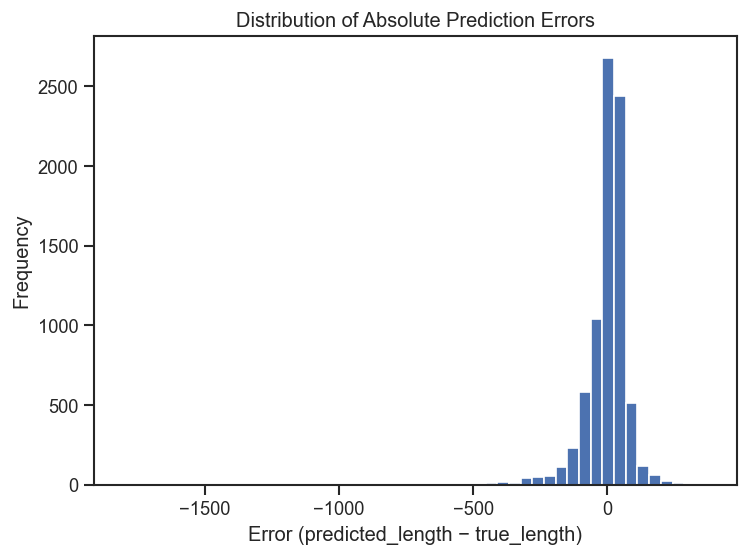

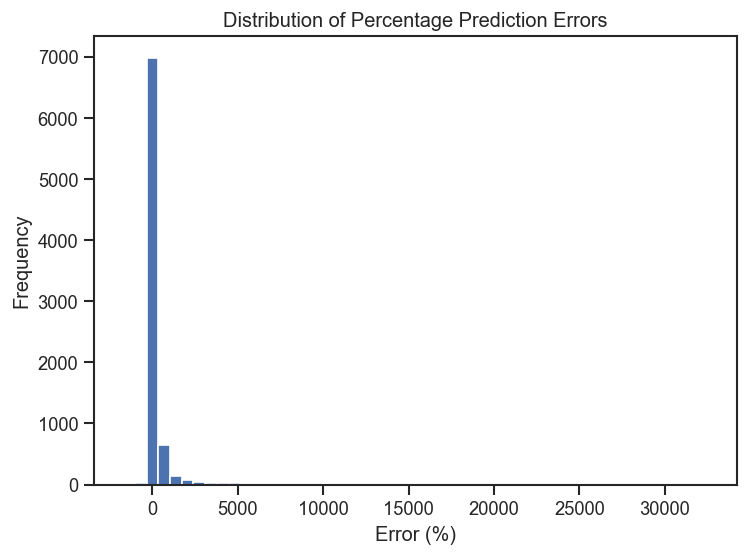

In [ ]:
# ─── 12) Final Model Error Statistics ─────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kurtosis

# Use the current test split and the engineered-features model as the final predictor
y_true = test_df["length"].values
model_final = model_feat
test_pool_full = test_pool_feat
y_pred = model_final.predict(test_pool_full).round().astype(int)

# ─── 12-A) Compute errors ─────────────────────────────────────────────────────
errors_abs = y_pred - y_true
errors_pct = (errors_abs / y_true) * 100  # percentage error

# ─── 12-B) Calculate statistics ───────────────────────────────────────────────
stats = {
    "Absolute Error": {
        "Mean": np.mean(errors_abs),
        "Median": np.median(errors_abs),
        "Variance": np.var(errors_abs),
        "Std Dev": np.std(errors_abs),
        "Kurtosis": kurtosis(errors_abs)
    },
    "Percentage Error": {
        "Mean (%)": np.mean(errors_pct),
        "Median (%)": np.median(errors_pct),
        "Variance (%)": np.var(errors_pct),
        "Std Dev (%)": np.std(errors_pct),
        "Kurtosis (%)": kurtosis(errors_pct)
    }
}

# Print stats
for err_type, metrics in stats.items():
    print(f"\n{err_type} Statistics:")
    for name, val in metrics.items():
        print(f"  {name}: {val:.2f}")

# ─── 12-C) Plot Absolute Error Distribution ──────────────────────────────────
plt.figure()
plt.hist(errors_abs, bins=50)
plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Error (predicted_length − true_length)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ─── 12-D) Plot Percentage Error Distribution ────────────────────────────────
plt.figure()
plt.hist(errors_pct, bins=50)
plt.title("Distribution of Percentage Prediction Errors")
plt.xlabel("Error (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



Absolute Error (Fixed=524) Statistics:
  Mean: 428.75
  Median: 461.00
  Variance: 13092.76
  Std Dev: 114.42
  Kurtosis: 22.40

Percentage Error (Fixed=524) Statistics:
  Mean (%): 2703.30
  Median (%): 731.75
  Variance (%): 44856765.06
  Std Dev (%): 6697.52
  Kurtosis (%): 34.31


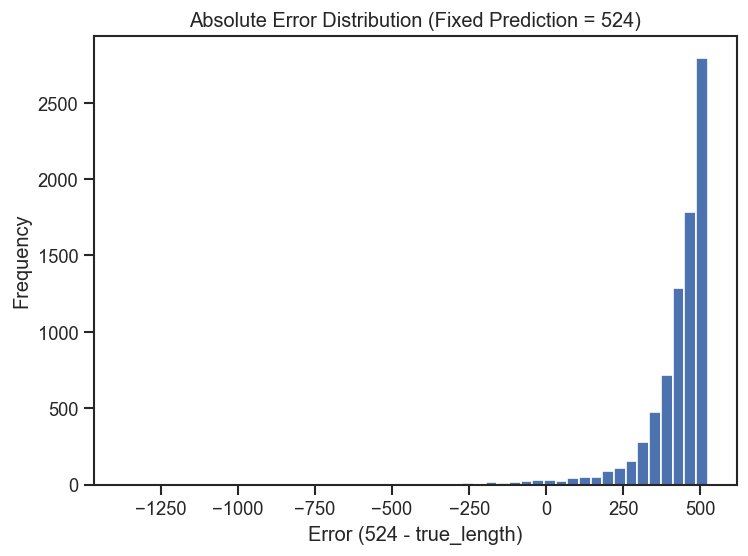

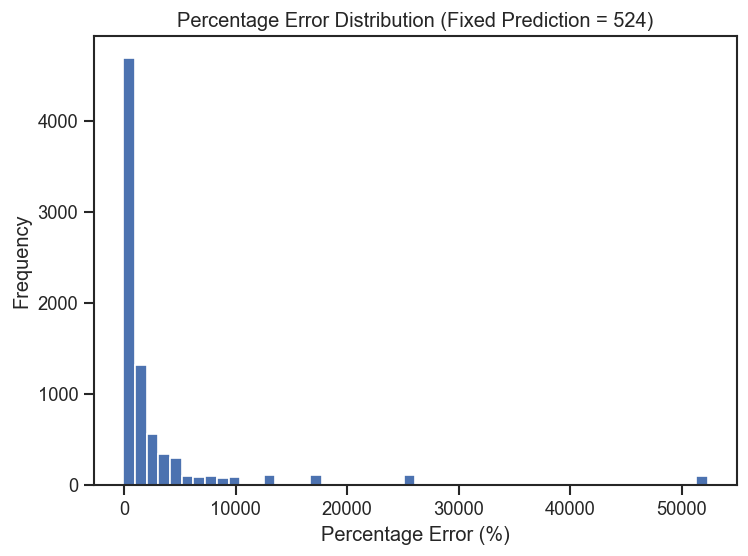

In [ ]:
# ─── 13) Fixed-Predictor Error Analysis ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kurtosis

# Recompute true lengths if needed
y_true = test_df["length"].values

fixed_pred = 524

# Errors if always predicting 524
errors_abs_fixed = fixed_pred - y_true
errors_pct_fixed = (errors_abs_fixed / y_true) * 100

# Compute statistics
stats_fixed = {
    "Absolute Error (Fixed=524)": {
        "Mean": np.mean(errors_abs_fixed),
        "Median": np.median(errors_abs_fixed),
        "Variance": np.var(errors_abs_fixed),
        "Std Dev": np.std(errors_abs_fixed),
        "Kurtosis": kurtosis(errors_abs_fixed)
    },
    "Percentage Error (Fixed=524)": {
        "Mean (%)": np.mean(errors_pct_fixed),
        "Median (%)": np.median(errors_pct_fixed),
        "Variance (%)": np.var(errors_pct_fixed),
        "Std Dev (%)": np.std(errors_pct_fixed),
        "Kurtosis (%)": kurtosis(errors_pct_fixed)
    }
}

# Print stats
for err_type, metrics in stats_fixed.items():
    print(f"\n{err_type} Statistics:")
    for name, val in metrics.items():
        print(f"  {name}: {val:.2f}")

# Plot distributions
plt.figure()
plt.hist(errors_abs_fixed, bins=50)
plt.title("Absolute Error Distribution (Fixed Prediction = 524)")
plt.xlabel("Error (524 - true_length)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(errors_pct_fixed, bins=50)
plt.title("Percentage Error Distribution (Fixed Prediction = 524)")
plt.xlabel("Percentage Error (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
